# Двухпараметрическое исследование
§6.2: исходные 15 значений β повторяются при γ=.05, .1, .2; всего 45 ОДУ.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
include(srcdir("experiment_support.jl"))

animate_sir

## Расчёты и отдельное уточнение пика

In [2]:
rows = NamedTuple[]
for γ in [0.05, 0.1, 0.2], β in 0.1:0.05:0.8
    net, u0, _ = build_sir_network(β, γ)
    df = simulate_deterministic(net, u0, (0.0, 100.0); saveat=0.5, rates=[β, γ])
    peak = refined_peak(net, u0, (0.0, 100.0); rates=[β, γ])
    push!(rows, (β=β, γ=γ, peak_I=maximum(df.I), final_R=df.R[end],
        refined_peak=peak.peak, peak_time=peak.time))
end
df_scan_param = DataFrame(rows)
save_table("sir_scan_param.csv", df_scan_param)
first(df_scan_param, 15)

Row,β,γ,peak_I,final_R,refined_peak,peak_time
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.1,0.05,977.56,993.247,995.705,0.122131
2,0.15,0.05,976.809,993.252,997.001,0.0840926
3,0.2,0.05,976.434,993.254,997.679,0.0644953
4,0.25,0.05,976.209,993.256,998.099,0.0524824
5,0.3,0.05,976.059,993.257,998.385,0.0443393
6,0.35,0.05,975.952,993.258,998.594,0.0384432
7,0.4,0.05,975.872,993.258,998.753,0.03397
8,0.45,0.05,975.809,993.259,998.878,0.0304562
9,0.5,0.05,975.759,993.259,998.98,0.0276204


## Две панели: дискретный и уточнённый пик

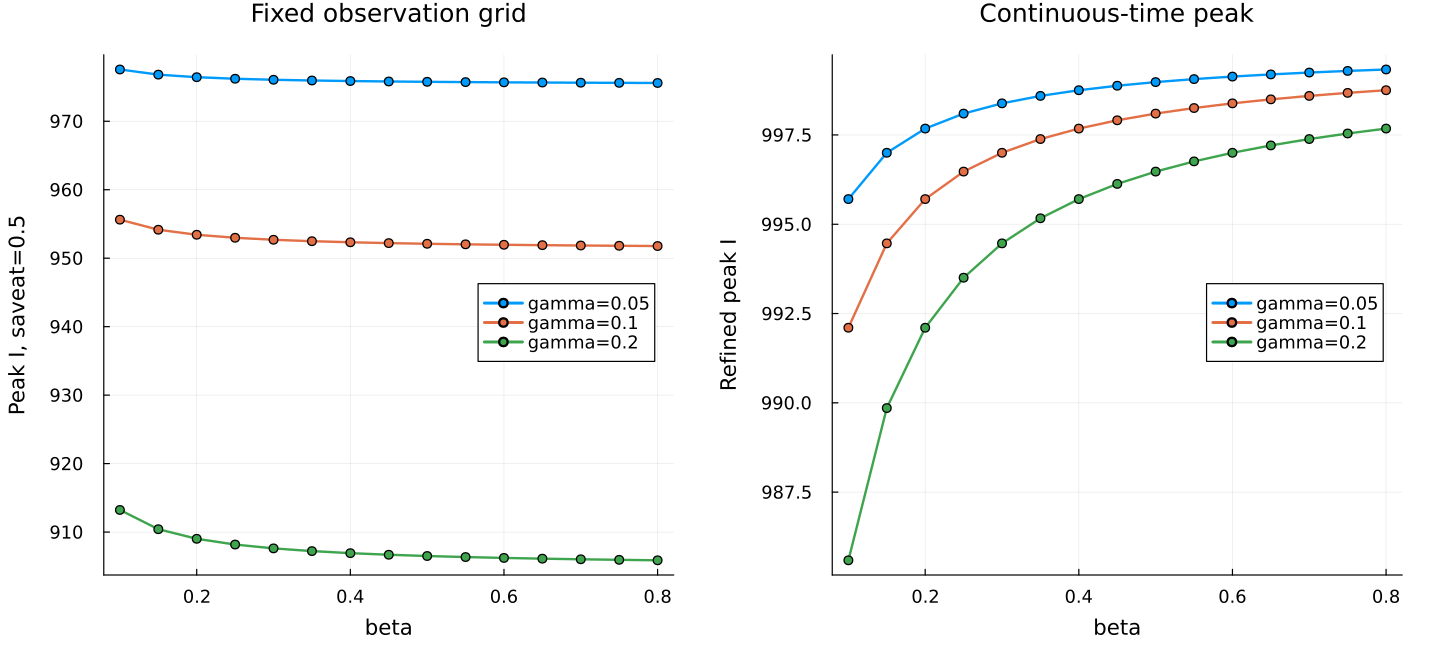

In [3]:
p_grid = plot(; xlabel="beta", ylabel="Peak I, saveat=0.5", title="Fixed observation grid")
p_refined = plot(; xlabel="beta", ylabel="Refined peak I", title="Continuous-time peak")
for γ in [0.05, 0.1, 0.2]
    d = df_scan_param[df_scan_param.γ .== γ, :]
    plot!(p_grid, d.β, d.peak_I; marker=:circle, label="gamma=$(γ)")
    plot!(p_refined, d.β, d.refined_peak; marker=:circle, label="gamma=$(γ)")
end
p = plot(p_grid, p_refined; layout=(1,2), size=(1200,540))
savefig(p, imagepath("11-plot.png"))
display(p)